In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# Load Iris Dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (150, 4)
Output Shape: (150,)


In [5]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


In [6]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Normalized Successfully")

Data Normalized Successfully


In [7]:
# Convert output labels into categorical values

y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

print("Categorical Labels:")
print(y_train[:5])

Categorical Labels:
[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [8]:
# Create Logistic Regression Model

model = tf.keras.Sequential([
    
    tf.keras.layers.Dense(
        3,
        activation='softmax',
        input_shape=(4,)
    )
])

print("Model Created Successfully")

Model Created Successfully


In [9]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [15]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2
)

print("Training Completed")

Epoch 1/100
 1/12 [=>............................] - ETA: 0s - loss: 0.2540 - accuracy: 1.0000

12/12 [==============================] - 0s 26ms/step - loss: 0.4092 - accuracy: 0.8438 - val_loss: 0.4505 - val_accuracy: 0.8750
Epoch 2/100
12/12 [==============================] - 0s 13ms/step - loss: 0.4076 - accuracy: 0.8438 - val_loss: 0.4481 - val_accuracy: 0.8750
Epoch 3/100
12/12 [==============================] - 0s 11ms/step - loss: 0.4058 - accuracy: 0.8438 - val_loss: 0.4464 - val_accuracy: 0.8750
Epoch 4/100
12/12 [==============================] - 0s 9ms/step - loss: 0.4042 - accuracy: 0.8438 - val_loss: 0.4451 - val_accuracy: 0.8750
Epoch 5/100
12/12 [==============================] - 0s 9ms/step - loss: 0.4025 - accuracy: 0.8438 - val_loss: 0.4433 - val_accuracy: 0.8750
Epoch 6/100
12/12 [==============================] - 0s 26ms/step - loss: 0.4009 - accuracy: 0.8438 - val_loss: 0.4413 - val_accuracy: 0.8750
Epoch 7/100
12/12 [==============================] - 0s 11ms/step - loss: 0.3996 - accuracy: 0.8438 - val_loss: 0.4403 - val_accuracy: 0.8750
Epoch 8/100
12/12 [=

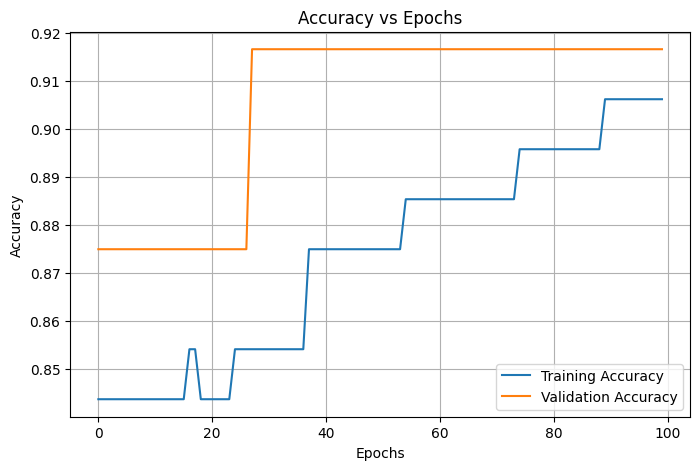

In [17]:
# Plot Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")

plt.legend()
plt.grid(True)

plt.show()

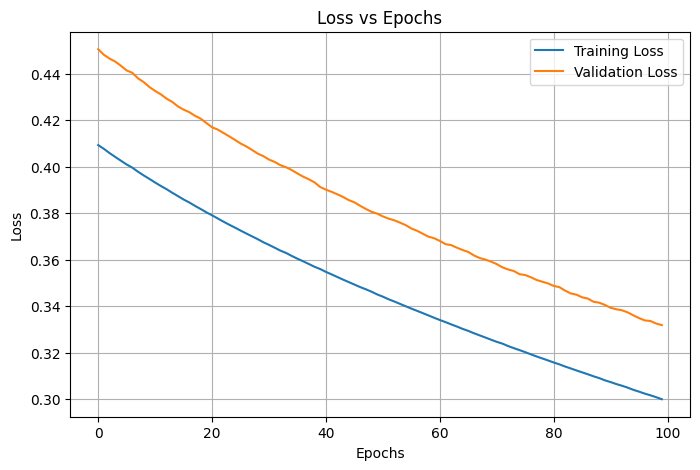

In [18]:
# Plot Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Evaluate model performance

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 [==============================] - 0s 70ms/step - loss: 0.2546 - accuracy: 0.9667
Test Loss: 0.2546057403087616
Test Accuracy: 0.9666666388511658


In [20]:
# Predict sample data

sample = np.array([[5.1, 3.5, 1.4, 0.2]])

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("Prediction Probabilities:")
print(prediction)

predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)

1/1 [==============================] - 0s 54ms/step
Prediction Probabilities:
[[9.7914428e-01 2.0148125e-02 7.0756080e-04]]
Predicted Class: 0
